# Обучение модели

In [2]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

optuna.logging.set_verbosity(optuna.logging.WARNING)

DATA_PATH = Path("../data/creditcard.csv")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_VERSION = "v1"

# 1. Загрузка данных, Stratified Split и масштабирование

In [3]:
df = pd.read_csv(DATA_PATH)
X = df.drop(columns=["Class"])
y = df["Class"]

X_train_raw, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

scaler = RobustScaler()
cols_to_scale = ["Time", "Amount"]

X_train = X_train_raw.copy()
X_val = X_val_raw.copy()
X_test = X_test_raw.copy()

X_train[cols_to_scale] = scaler.fit_transform(X_train_raw[cols_to_scale])
X_val[cols_to_scale] = scaler.transform(X_val_raw[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test_raw[cols_to_scale])

scaler_path = MODELS_DIR / "scaler.joblib"
joblib.dump(scaler, scaler_path)

print(
    f"Размеры выборок: Train={X_train.shape[0]}, Val={X_val.shape[0]}, Test={X_test.shape[0]}"
)
print(
    f"Доля фрода в Train: {y_train.mean():.4%}, Val: {y_val.mean():.4%}, Test: {y_test.mean():.4%}"
)

Размеры выборок: Train=170884, Val=56961, Test=56962
Доля фрода в Train: 0.1726%, Val: 0.1720%, Test: 0.1738%


# 2. Подбор гиперпараметров CatBoost через Optuna (Целевая метрика: PR-AUC)

In [4]:
def objective(trial: optuna.Trial) -> float:
    params = {
        "iterations": trial.suggest_int("iterations", 300, 800),
        "depth": trial.suggest_int("depth", 4, 8),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.15, log=True
        ),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
        "scale_pos_weight": trial.suggest_float(
            "scale_pos_weight", 1.0, 50.0
        ),
        "eval_metric": "Logloss",
        "random_seed": 42,
        "verbose": False,
    }

    model = CatBoostClassifier(**params)
    model.fit(
        X_train,
        y_train,
        eval_set=(X_val, y_val),
        early_stopping_rounds=50,
        verbose=False,
    )

    preds_val_proba = model.predict_proba(X_val)[:, 1]

    pr_auc = average_precision_score(y_val, preds_val_proba)
    return pr_auc


print("Запуск оптимизации Optuna (50 триалов)...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params
print("\nЛучшие гиперпараметры Optuna:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"Лучший PR-AUC на валидации: {study.best_value:.4f}")

Запуск оптимизации Optuna (50 триалов)...


Best trial: 31. Best value: 0.827714: 100%|██████████| 50/50 [01:08<00:00,  1.37s/it]


Лучшие гиперпараметры Optuna:
  iterations: 649
  depth: 5
  learning_rate: 0.08794890301571216
  l2_leaf_reg: 0.07950689181024591
  scale_pos_weight: 1.2165068277456967
Лучший PR-AUC на валидации: 0.8277


# 3. Обучение финальной модели CatBoost

In [5]:
final_params = {
    **best_params,
    "eval_metric": "Logloss",
    "random_seed": 42,
    "verbose": 100,
}

print("Обучение финальной модели...")
final_model = CatBoostClassifier(**final_params)
final_model.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50,
)

print("Финальная модель успешно обучена!")

Обучение финальной модели...
0:	learn: 0.3841087	test: 0.3843739	best: 0.3843739 (0)	total: 6.53ms	remaining: 4.23s
100:	learn: 0.0014205	test: 0.0034890	best: 0.0034545 (93)	total: 599ms	remaining: 3.25s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.003433727546
bestIteration = 144

Shrink model to first 145 iterations.
Финальная модель успешно обучена!


# 4. Подбор оптимального Decision Threshold по F1-Score на Валидации

In [6]:
val_proba = final_model.predict_proba(X_val)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_val, val_proba)

f1_scores = np.divide(
    2 * (precisions * recalls),
    (precisions + recalls),
    out=np.zeros_like(precisions),
    where=(precisions + recalls) != 0,
)

best_idx = np.argmax(f1_scores)
optimal_threshold = float(thresholds[best_idx])
best_val_f1 = float(f1_scores[best_idx])

print(
    f"Оптимальный порог (Decision Threshold) на Validation: {optimal_threshold:.4f}"
)
print(f"Максимальный F1-Score на Validation: {best_val_f1:.4f}")

Оптимальный порог (Decision Threshold) на Validation: 0.4560
Максимальный F1-Score на Validation: 0.8444


# 5. Оценка модели на отложенном тесте

ТЕСТОВЫЕ МЕТРИКИ (Model Version: v1)
ROC-AUC: 0.9716
PR-AUC : 0.8755

Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56863
       Fraud       0.96      0.81      0.88        99

    accuracy                           1.00     56962
   macro avg       0.98      0.90      0.94     56962
weighted avg       1.00      1.00      1.00     56962



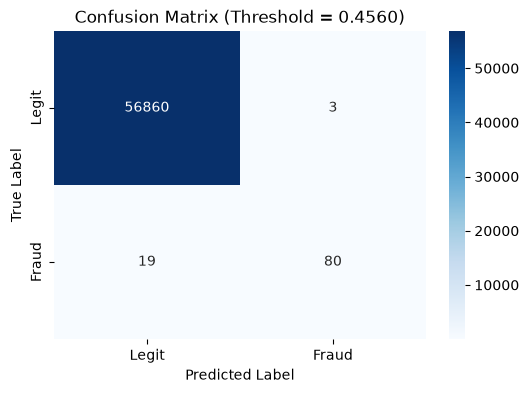

In [7]:
test_proba = final_model.predict_proba(X_test)[:, 1]

y_test_pred = (test_proba >= optimal_threshold).astype(int)

test_roc_auc = roc_auc_score(y_test, test_proba)
test_pr_auc = average_precision_score(y_test, test_proba)

print(f"ТЕСТОВЫЕ МЕТРИКИ (Model Version: {MODEL_VERSION})")
print(f"ROC-AUC: {test_roc_auc:.4f}")
print(f"PR-AUC : {test_pr_auc:.4f}\n")

print("Classification Report:")
print(
    classification_report(
        y_test, y_pred=y_test_pred, target_names=["Legit", "Fraud"]
    )
)

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legit", "Fraud"],
    yticklabels=["Legit", "Fraud"],
)
plt.title(f"Confusion Matrix (Threshold = {optimal_threshold:.4f})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# 6. Сохранение артефактов

In [8]:
model_path = MODELS_DIR / f"catboost_fraud_{MODEL_VERSION}.cbm"
final_model.save_model(str(model_path))

feature_names = list(X.columns)

metadata = {
    "model_version": MODEL_VERSION,
    "model_type": "CatBoostClassifier",
    "optimal_threshold": round(optimal_threshold, 4),
    "feature_names": feature_names,
    "scaled_features": cols_to_scale,
    "metrics": {
        "val_f1": round(best_val_f1, 4),
        "test_roc_auc": round(test_roc_auc, 4),
        "test_pr_auc": round(test_pr_auc, 4),
    },
}

metadata_path = MODELS_DIR / "metadata.json"
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

print("Успешно сохранены все артефакты:")
print(f" 1. Scaler:   {scaler_path}")
print(f" 2. Model:    {model_path}")
print(f" 3. Metadata: {metadata_path}")

Успешно сохранены все артефакты:
 1. Scaler:   ../models/scaler.joblib
 2. Model:    ../models/catboost_fraud_v1.cbm
 3. Metadata: ../models/metadata.json
